# 频率测量方法精度比较

比较单点 $f_{01}$ 测量的几种方法在不同 flux 偏置点、不同失谐 $\Delta$ 下的精度：

| 方法 | 调用 | 说明 |
|---|---|---|
| **Ramsey 双扫** | `FrequencyMeasurement(method="ramsey", f_artificial=None)` | 扫自由演化时间 $\tau$ + FFT 取峰，金标准，无歧义无界 |
| **瞬态 低阶 (order=1)** | `method="transient", order=1` | 线性 $\Delta = p_{\rm diff}/G_{\rm freq}$ |
| **瞬态 高阶 — 拟合** | `order=3, g3_source="fit"` | 三次 Newton，$G_3$ 来自 $p_{\rm diff}(\Delta)$ 奇多项式拟合（自适应区间） |
| **瞬态 高阶 — 完整核** | `order=3, g3_source="kernel_full"` | 三次 Newton，$G_3=\iiint k_3\,dt^3$（完整非对角 Heisenberg 核） |

**约定**：`flux` 参数是相对偏置点的**偏移** $\delta\Phi$（`qubit_in_mag` 内部叠加 `qubit.flux`）。
横轴 = 总 flux = 偏置 + $\delta\Phi$。$\Delta = f_q(\text{总flux}) - \omega_d$，$\omega_d = f_q(\text{偏置})$。

为加速，每个偏置点只标定一次（$G_{\rm freq}, G_1, G_3$），每个 flux 点只跑 2 次 mesolve 求 $p_{\rm diff}$ 后用
确定性公式反演（与 `sqc/calibration/frequency.py:_measure_frequency_transient` 同一 $\delta\omega=-\Delta$ 约定）。

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from qutip import QobjEvo, basis, mesolve

from sqc.config import CONFIG
from sqc.control.sequence import create_ramsey_pulse
from sqc.control.flux_signal import FluxSignal
from sqc.reconstruction.kernel import KernelEstimator
from sqc.calibration.frequency import (
    FrequencyMeasurement, _calibrate_g3_taylor, _calibrate_g3_kernel_full, _g3_cache,
)
from src.qubit import TransmonQubit

rcParams.update({'font.size': 11, 'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# --- qubit params ---
EC, EJ = 0.2 * 2 * np.pi, 15 * 2 * np.pi   # rad*GHz
DT = CONFIG.awg.dt
T_RABI = CONFIG.pulse.t_rabi.copy()
T_GLOBAL = CONFIG.pulse.make_time(0, 40)    # short axis (pulse ~20 ns) for speed

def make_qubit(flux):
    return TransmonQubit(EC=EC, EJ=EJ, T1=10000, T2=5000, n_levels=2, flux=flux)

def true_fq(total_flux):
    """True qubit frequency (rad*GHz) at an absolute total flux."""
    EJ_f = EJ * abs(math.cos(math.pi * total_flux))
    return np.sqrt(8 * EJ_f * EC) - EC

In [2]:
def _newton(p_diff, G_lin, G3, n_iter=60):
    """Solve p_diff = G_lin*dw + (G3/6)*dw^3 for dw (= delta_omega = -Delta).
    Same as sqc/calibration/frequency.py:_measure_frequency_transient."""
    if abs(G_lin) < 1e-12:
        return 0.0
    dw = p_diff / G_lin
    if abs(G3) < 1e-10:
        return dw
    for _ in range(n_iter):
        f = G_lin * dw + (G3 / 6.0) * dw**3 - p_diff
        fp = G_lin + (G3 / 2.0) * dw**2
        if abs(fp) < 1e-15:
            break
        dw_new = dw - f / fp
        if abs(dw_new - dw) < 1e-12 * max(abs(dw), 1e-12):
            dw = dw_new; break
        dw = dw_new
    return dw


def precompute(qb, omega_d):
    """One-time calibration at the bias point: G_freq, (G1,G3)_fit, (G1,G3)_kernel_full."""
    # seat qubit at the bias (zero applied signal -> total flux = qb.flux)
    qb.qubit_in_mag(FluxSignal(type=0, t_list=CONFIG.pulse.make_time(0, 300)),
                    frame=1, omega_d=omega_d)
    cx = create_ramsey_pulse(T_RABI, 0.0, omega_d=omega_d, phase1=np.pi/2, phase2=0.0, qubit=qb)
    cmx = create_ramsey_pulse(T_RABI, 0.0, omega_d=omega_d, phase1=np.pi/2, phase2=np.pi, qubit=qb)

    # G_freq: order-1 omega (Virtual-Z) kernel, delta-p / delta-(phase kick)
    est = KernelEstimator(mode='omega', method='exp', order=1, virtual_z_impl='math')
    rx, rmx = est.estimate_full(cx, qb), est.estimate_full(cmx, qb)
    G_freq = float(np.trapezoid((rx.kernels[0] - rmx.kernels[0]) / 2.0, rx.t_samples))

    _g3_cache.clear()
    G1_fit, G3_tay = _calibrate_g3_taylor(qb, omega_d, T_RABI, T_GLOBAL)   # Delta convention
    G1_kf, G3_kf = _calibrate_g3_kernel_full(qb, omega_d, T_RABI)          # dw = -Delta convention
    return dict(cx=cx, cmx=cmx, G_freq=G_freq,
                G1_fit=G1_fit, G3_tay=G3_tay, G1_kf=G1_kf, G3_kf=G3_kf)


def measure_transient(qb, omega_d, dphi, pc):
    """Return (order1, order3_fit, order3_kernel_full) frequencies at offset dphi."""
    Phi = FluxSignal(type=1 if dphi != 0 else 0,
                     t_list=CONFIG.pulse.make_time(0, 300), amplitude=float(dphi))
    qb.qubit_in_mag(Phi, frame=1, omega_d=omega_d)
    psi_e = basis(qb.n_levels, 1)
    Hb = QobjEvo(qb.H_list, tlist=qb.mag_signal.t_list, order=1)
    p = []
    for c in (pc['cx'], pc['cmx']):
        H = Hb + QobjEvo(c.hamiltonian_on(T_GLOBAL), tlist=T_GLOBAL, order=1)
        p.append(float(mesolve(H, qb.state, T_GLOBAL, [], e_ops=[psi_e * psi_e.dag()],
                               options={'max_step': float(DT)}).expect[0][-1]))
    p_diff = (p[0] - p[1]) / 2.0
    f1 = omega_d - p_diff / pc['G_freq']
    f3 = omega_d - _newton(p_diff, -pc['G1_fit'], -pc['G3_tay'])   # Route A: negate to dw convention
    fk = omega_d - _newton(p_diff, pc['G1_kf'], pc['G3_kf'])       # Route B: raw kernel integrals
    return f1, f3, fk

In [3]:
def run_bias(bias, dphi_max=0.010, n_pts=13, include_ramsey=True,
             ramsey_tau_max=200.0):
    """Sweep total flux = bias + dphi; measure all methods; return a results dict.

    NOTE on time axes: the transient method uses the short T_GLOBAL (pulse is
    ~20 ns; constant detuning after the pulse does not change p_e), but the
    Ramsey tau-sweep places the 2nd pi/2 pulse at tau (up to ramsey_tau_max),
    so its mesolve axis MUST cover pulse + max tau -- otherwise the late pulse
    falls outside hamiltonian_on(t_global) and is silently dropped, corrupting
    the sweep. Ramsey gets its own t_global = make_time(0, tau_max + 40).
    """
    qb = make_qubit(bias)
    omega_d = qb.frequency                         # = true_fq(bias)
    pc = precompute(qb, omega_d)

    ramsey_taus = CONFIG.pulse.make_time(0, ramsey_tau_max)
    ramsey_tg = CONFIG.pulse.make_time(0, ramsey_tau_max + 40)   # cover full sequence

    dphis = np.linspace(0.0, dphi_max, n_pts)
    total_flux = bias + dphis
    f_true = np.array([true_fq(tf) for tf in total_flux])

    f1 = np.zeros(n_pts); f3 = np.zeros(n_pts); fk = np.zeros(n_pts); fr = np.full(n_pts, np.nan)
    for i, d in enumerate(dphis):
        f1[i], f3[i], fk[i] = measure_transient(qb, omega_d, d, pc)
        if include_ramsey:
            m = FrequencyMeasurement(qb, method='ramsey', f_artificial=None,
                                     tau_list=ramsey_taus, t_global=ramsey_tg)
            fr[i] = m.measure(d)
    return dict(bias=bias, total_flux=total_flux,
                Delta_mhz=(f_true - omega_d) / (2*np.pi) * 1e3,
                f_true=f_true, omega_d=omega_d,
                ramsey=fr, order1=f1, fit=f3, kfull=fk, pc=pc)


def plot_bias(res):
    """Two-panel: frequency vs flux (left) and measurement error vs flux (right)."""
    tf = res['total_flux']; GHZ = 2*np.pi
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))
    # -- left: f vs flux --
    axL.plot(tf, res['f_true']/GHZ, 'k-', lw=2, label='True $f_q$', zorder=1)
    if np.any(np.isfinite(res['ramsey'])):
        axL.plot(tf, res['ramsey']/GHZ, 'o', color='tab:blue', ms=6, label='Ramsey double-sweep')
    axL.plot(tf, res['order1']/GHZ, '^', color='tab:red', ms=6, label='Transient order-1 (linear)')
    axL.plot(tf, res['fit']/GHZ, 's', color='tab:green', ms=5, label='Transient order-3 (fit)')
    axL.plot(tf, res['kfull']/GHZ, 'D', color='tab:purple', ms=4, label='Transient order-3 (kernel_full)')
    axL.axvline(res['bias'], color='gray', ls='--', alpha=0.6, label='Bias point')
    axL.set_xlabel('Total flux ($\Phi_0$)'); axL.set_ylabel('Qubit frequency (GHz)')
    axL.set_title(f'Frequency vs flux (bias={res["bias"]})'); axL.legend(fontsize=9)
    # -- right: error vs flux (MHz) --
    err = lambda f: (f - res['f_true'])/GHZ*1e3
    if np.any(np.isfinite(res['ramsey'])):
        axR.plot(tf, err(res['ramsey']), 'o-', color='tab:blue', ms=5, label='Ramsey')
    axR.plot(tf, err(res['order1']), '^-', color='tab:red', ms=5, label='order-1')
    axR.plot(tf, err(res['fit']), 's-', color='tab:green', ms=5, label='order-3 fit')
    axR.plot(tf, err(res['kfull']), 'D-', color='tab:purple', ms=4, label='order-3 kernel_full')
    axR.axhline(0, color='gray', alpha=0.5)
    axR.set_xlabel('Total flux ($\Phi_0$)'); axR.set_ylabel('Measurement error (MHz)')
    axR.set_title(f'Measurement error vs flux  ($\Delta$ up to {res["Delta_mhz"][-1]:+.0f} MHz)')
    axR.legend(fontsize=9)
    plt.tight_layout()
    return fig

## 偏置点 1：sweet spot (flux = 0.0)

甜点处 $\partial f/\partial\Phi = 0$，给定 flux 窗口内 $\Delta$ 极小（亚 MHz）。所有方法都很准；
Ramsey 在 kHz 级，瞬态在亚 MHz 级。此处高阶修正收益不明显（$\Delta$ 太小）。

Kernel computation (omega, math) took 0.09 seconds
Kernel computation (omega, math) took 0.08 seconds


G3 Taylor calibration (adaptive): 0.2s, G1=-6.1582, G3=975.2, G3/G1=-158.4 ns^2


Heisenberg off-diagonal kernel (sim, order=3, M=39) took 0.54 seconds


Heisenberg off-diagonal kernel (sim, order=3, M=39) took 0.55 seconds


Delta range (MHz): [ 0.   -1.21]


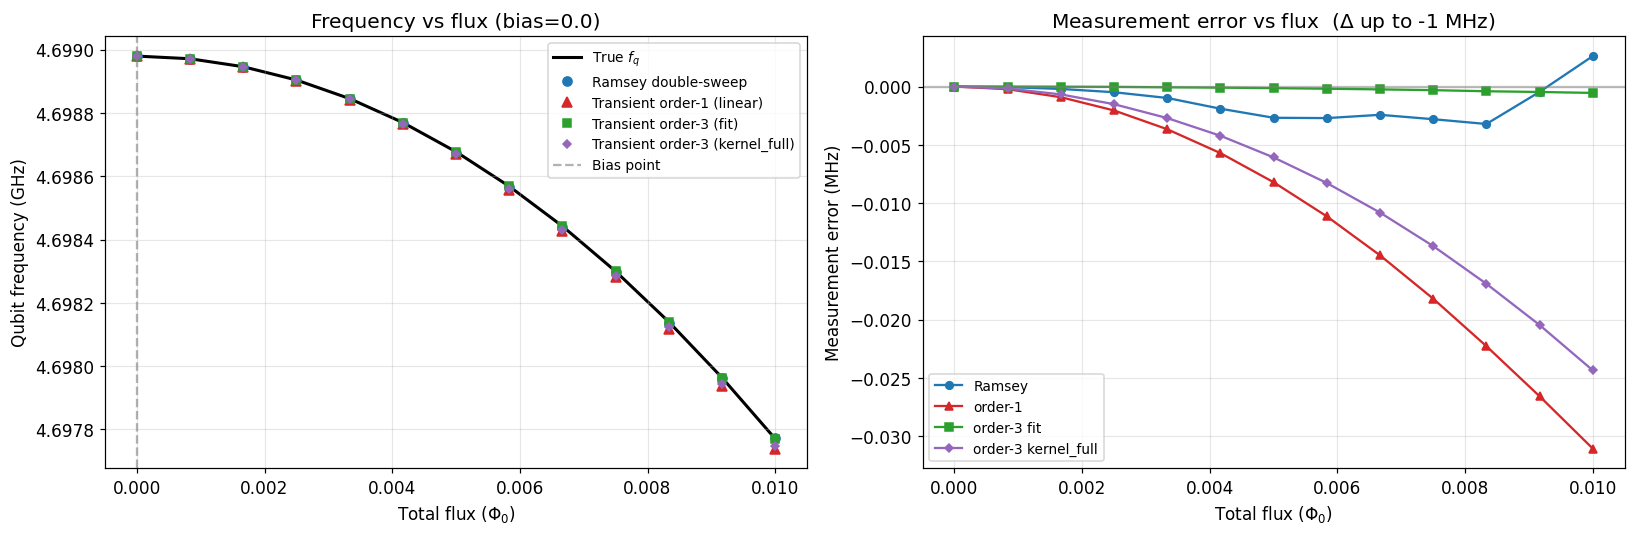

In [4]:
res0 = run_bias(0.0, dphi_max=0.010, n_pts=13, include_ramsey=True)
fig0 = plot_bias(res0)
fig0.savefig('frequency_compare_bias0.0.png', dpi=150, bbox_inches='tight')
print('Delta range (MHz):', np.round(res0['Delta_mhz'][[0, -1]], 2))
plt.show()

## 偏置点 2：biased (flux = 0.9，最大斜率附近)

偏置点斜率大，同样的 flux 窗口把 $\Delta$ 推到 ~20 MHz（接近翻折点）。这里能看出：

- **order-1 线性**最先失效（$\Delta$ 大时 $p_{\rm diff}$ 偏离线性）；
- **order-3 拟合 / 完整核**把可用区间向外推 ~1 个翻折半区，精度提升约 10×；
- 临近翻折点（$|\Delta|\to\Delta_{\rm fold}$）所有有限阶方法最终都失效；
- **Ramsey 双扫**全程无歧义（频率直接读取）。

Kernel computation (omega, math) took 0.08 seconds
Kernel computation (omega, math) took 0.08 seconds


G3 Taylor calibration (adaptive): 0.2s, G1=-6.1582, G3=975.2, G3/G1=-158.4 ns^2


Heisenberg off-diagonal kernel (sim, order=3, M=39) took 0.53 seconds


Heisenberg off-diagonal kernel (sim, order=3, M=39) took 0.54 seconds


Delta range (MHz): [ 0.   14.18]


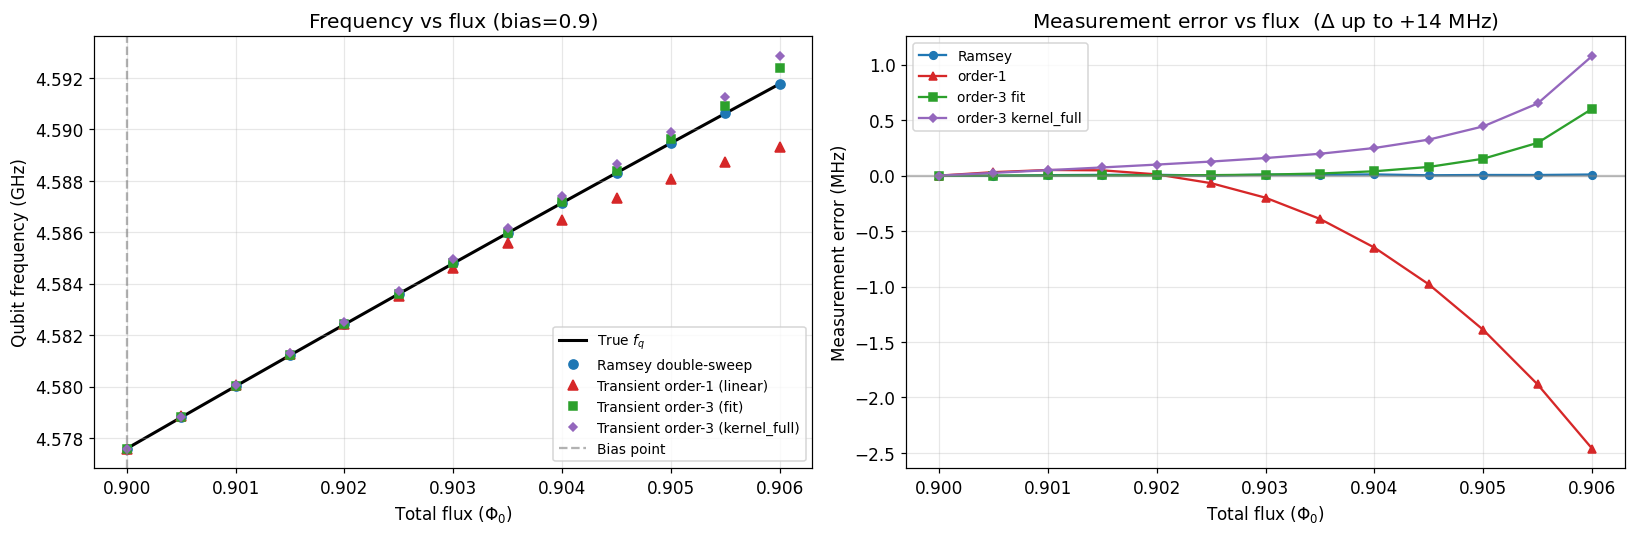

In [5]:
res9 = run_bias(0.9, dphi_max=0.006, n_pts=13, include_ramsey=True)
fig9 = plot_bias(res9)
fig9.savefig('frequency_compare_bias0.9.png', dpi=150, bbox_inches='tight')
print('Delta range (MHz):', np.round(res9['Delta_mhz'][[0, -1]], 2))
plt.show()

In [6]:
# RMS error summary (MHz) over the swept window
def rms(res, key):
    return float(np.sqrt(np.mean(((res[key] - res['f_true'])/(2*np.pi)*1e3)**2)))
print(f"{'bias':>6} | {'Ramsey':>8} {'order1':>8} {'fit':>8} {'kernel_full':>12}   [RMS err, MHz]")
for res in (res0, res9):
    print(f"{res['bias']:>6} | {rms(res,'ramsey'):>8.4f} {rms(res,'order1'):>8.4f} "
          f"{rms(res,'fit'):>8.4f} {rms(res,'kfull'):>12.4f}")

  bias |   Ramsey   order1      fit  kernel_full   [RMS err, MHz]
   0.0 |   0.0020   0.0151   0.0003       0.0116
   0.9 |   0.0065   1.0044   0.1923       0.3967


## 结论

1. **甜点 (flux=0)**：$\Delta$ 极小，瞬态各阶都准；Ramsey 最精（kHz）。
2. **偏置点 (flux=0.9)**：$\Delta$ 大，**order-3（fit / kernel_full）显著优于 order-1**，把瞬态可用量程向外推约半个翻折区（精度 ~10×）。fit 与 kernel_full 互为交叉验证。
3. **符号**：偏置点斜率正/负导致 $\Delta$ 正/负，order-3 在两种符号下都正确（已修复历史符号 bug）。
4. **天花板**：临近翻折点 $\Delta_{\rm fold}\approx\pi/(2T_{\rm eff})$ 时所有有限阶瞬态方法失效；大失谐应改用 **Ramsey 双扫**（无歧义、无界）。
5. 缩短 $\pi/2$ 脉冲可增大 $\Delta_{\rm fold}$（量程↑），但灵敏度按 $G_1\cdot\Delta_{\rm fold}=$const 同比下降。
6. **Ramsey 精度**:Ramsey 双扫达 ~kHz(bias=0.0: 2 kHz;bias=0.9: 6.5 kHz),是全程的金标准。关键:Ramsey 的 ``t_global`` 必须覆盖完整序列(脉冲 + 最大 τ),否则 ``hamiltonian_on`` 会把 τ 处的第二个 π/2 脉冲截断丢弃,使扫描失效——本 notebook 为 Ramsey 单独构造 ``make_time(0, tau_max+40)``。